In [2]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

os.makedirs("Plots", exist_ok=True)

df = pd.read_csv("airbnb_cleaned.csv")

print(df.head())
print(df.info())

                                             title        lat        lng  \
0  ETERNA.Suite W Jaccuzi, Pyramids View & Balcony  29.973873  31.146603   
1                                 king khufu suite  29.986300  31.143100   
2                             Akasia Pyramids View  29.978100  31.145400   
3          Mountain Cave | Pyramids View & Jacuzzi  29.979090  31.146920   
4                               Heaven of Pyramids  29.978787  31.144191   

   rating_overall  reviews_count  rating_accuracy  rating_cleanliness  \
0            4.95          133.0             4.96                4.92   
1            5.00           62.0             5.00                5.00   
2            4.91          176.0             4.91                4.91   
3            4.92           12.0             5.00                4.75   
4            4.71          125.0             4.74                4.61   

   rating_value  rating_location  price_total  price_original  \
0          4.92             4.79       

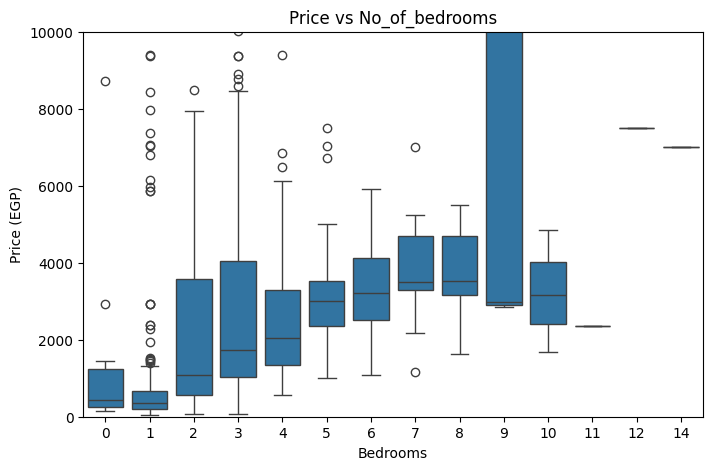

In [3]:
# Price vs Bedrooms
plt.figure(figsize=(8,5))
sns.boxplot(x=df['bedrooms'], y=df['price_total'])
plt.ylim(0, 10000)
plt.title("Price vs No_of_bedrooms")
plt.xlabel("Bedrooms")
plt.ylabel("Price (EGP)")
plt.savefig("Plots/price_vs_bedrooms.png")
plt.show()

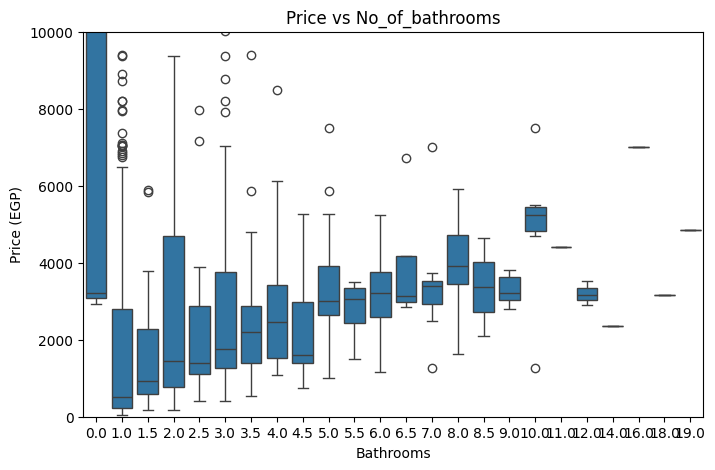

In [4]:
# Price vs Bathrooms
plt.figure(figsize=(8,5))
sns.boxplot(x=df['bathrooms'], y=df['price_total'])
plt.ylim(0, 10000)
plt.title("Price vs No_of_bathrooms")
plt.xlabel("Bathrooms")
plt.ylabel("Price (EGP)")
plt.savefig("Plots/price_vs_bathrooms.png")
plt.show()

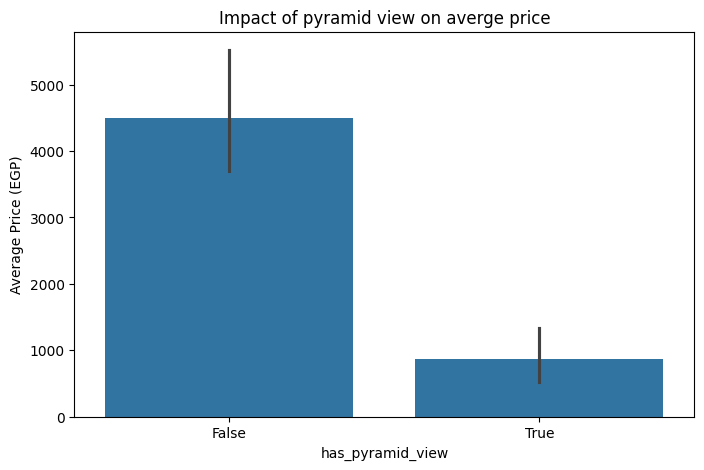

In [5]:
# Impact of pyramid view on averge price
plt.figure(figsize=(8,5))
sns.barplot(x=df['has_pyramid_view'], y=df['price_total'])
plt.title("Impact of pyramid view on averge price")
plt.xlabel("has_pyramid_view")
plt.ylabel("Average Price (EGP)")
plt.savefig("Plots/price_by_pyramid_view.png")
plt.show()

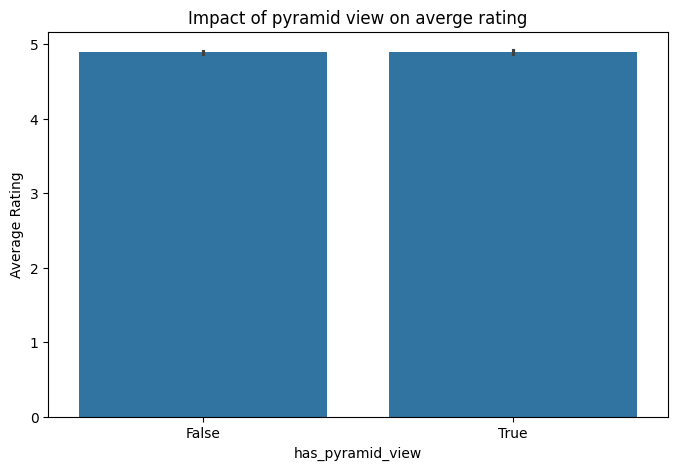

In [6]:
# Impact of pyramid view on averge rating
plt.figure(figsize=(8,5))
sns.barplot(x=df['has_pyramid_view'], y=df['rating_overall'])
plt.title("Impact of pyramid view on averge rating")
plt.xlabel("has_pyramid_view")
plt.ylabel("Average Rating")
plt.savefig("Plots/rating_by_pyramid_view.png")
plt.show()

In [7]:
# Amenities Comparison
amenities = ['has_wifi','has_pool','has_pyramid_view']
avg_prices = [df[df[a]==True]['price_total'].mean() for a in amenities]
avg_ratings = [df[df[a]==True]['rating_overall'].mean() for a in amenities]

/tmp/ipykernel_3759/1184239563.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=amenities, y=avg_prices, palette="viridis")


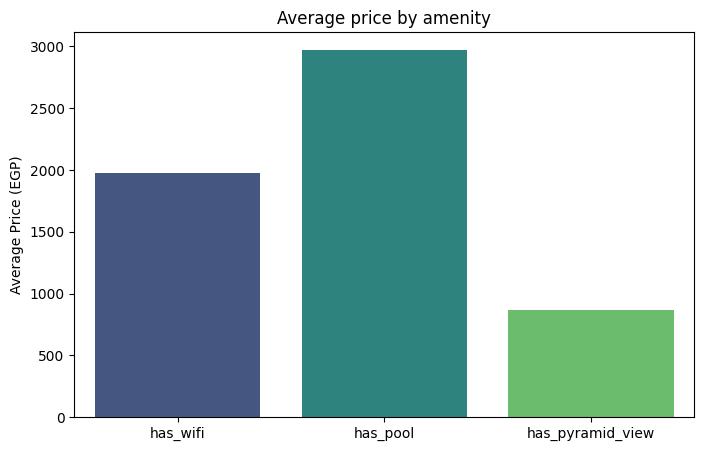

In [8]:
plt.figure(figsize=(8,5))
sns.barplot(x=amenities, y=avg_prices, palette="viridis")
plt.title("Average price by amenity")
plt.ylabel("Average Price (EGP)")
plt.savefig("Plots/price_by_amenity.png")
plt.show()

/tmp/ipykernel_3759/3570550393.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=amenities, y=avg_ratings, palette="magma")


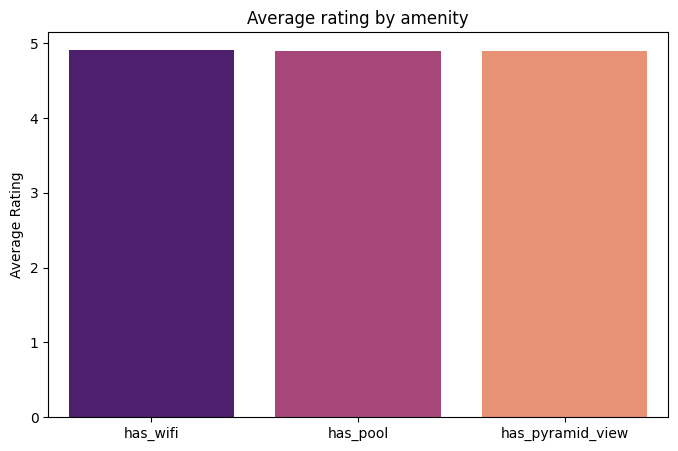

In [9]:
plt.figure(figsize=(8,5))
sns.barplot(x=amenities, y=avg_ratings, palette="magma")
plt.title("Average rating by amenity")
plt.ylabel("Average Rating")
plt.savefig("Plots/rating_by_amenity.png")
plt.show()

/tmp/ipykernel_3759/2473335748.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=top_reviews['title'], x=top_reviews['reviews_count'], palette="coolwarm")


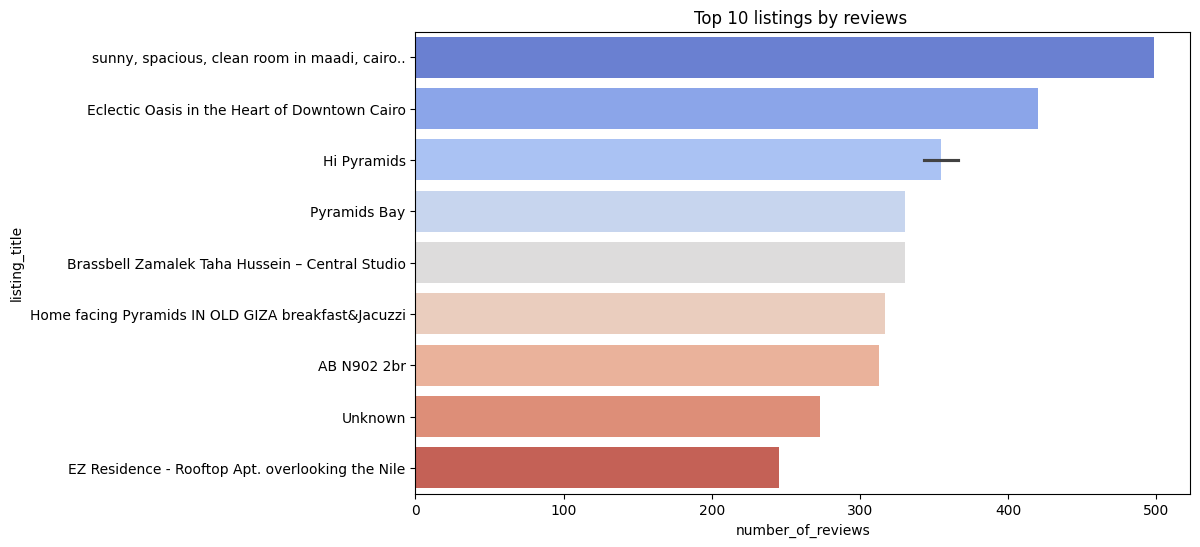

In [10]:
# Top 10 listings by reviews
top_reviews = df.nlargest(10, 'reviews_count')[['title','reviews_count','rating_overall','price_total']]
plt.figure(figsize=(10,6))
sns.barplot(y=top_reviews['title'], x=top_reviews['reviews_count'], palette="coolwarm")
plt.title("Top 10 listings by reviews ")
plt.xlabel("number_of_reviews")
plt.ylabel("listing_title")
plt.savefig("Plots/top10_reviews.png")
plt.show()